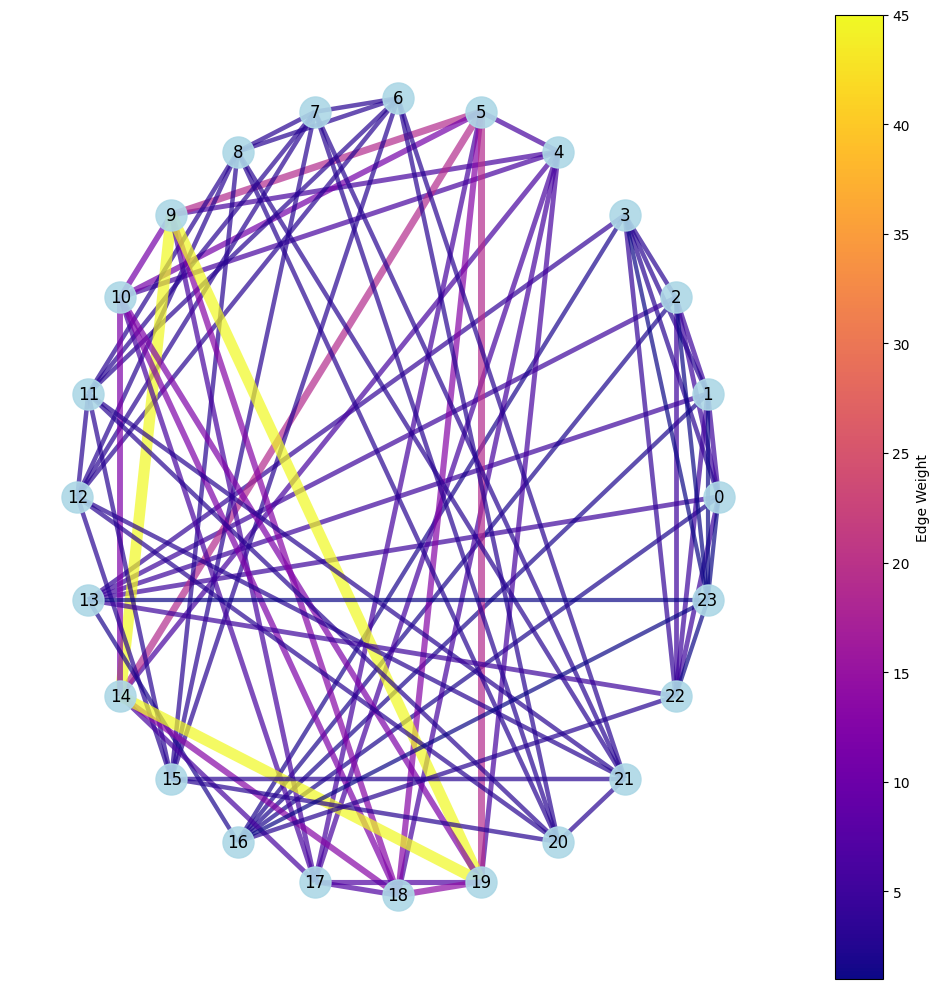

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx
import json

# Load the JSON file
with open('adjacency_matrix.json', 'r') as f:
    adjacency_matrix = json.load(f)

def create_network_graph(adjacency_matrix, node_labels=None, cmap='viridis', edge_scale=2, node_size=500):
    """
    Create a network graph from an adjacency matrix using the spring layout (force-directed layout).
    
    Parameters:
    adjacency_matrix: 2D numpy array or list of lists where entry [i,j] is the weight between nodes i and j
    node_labels: Optional list of labels for nodes. If None, numeric indices will be used
    cmap: Matplotlib colormap for edge colors (default: viridis)
    edge_scale: Factor to scale edge widths (default: 2)
    node_size: Size of nodes in the graph (default: 500)
    """
    # Convert matrix to numpy array if it's not already
    matrix = np.array(adjacency_matrix)
    
    # Create graph
    G = nx.Graph()
    
    # Add nodes
    n_nodes = matrix.shape[0]
    if node_labels is None:
        node_labels = [str(i) for i in range(n_nodes)]
    
    for i in range(n_nodes):
        G.add_node(i, label=node_labels[i])
    
    # Add edges with weights
    for i in range(n_nodes):
        for j in range(i+1, n_nodes):  # Avoid duplicate edges
            if matrix[i, j] > 0:  # Only add edges with positive weights
                G.add_edge(i, j, weight=matrix[i, j])
    
    # Get position layout using spring layout (force-directed layout)
    pos = nx.circular_layout(G)
    
    # Setup plot
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Get edge weights for coloring and thickness
    edges = G.edges()
    weights = [G[u][v]['weight'] for u, v in edges]
    
    # Normalize weights for visual scaling
    if weights:  # Check if there are any edges
        min_weight = min(weights)
        max_weight = max(weights)
        norm_weights = [(w - min_weight) / (max_weight - min_weight) if max_weight > min_weight else 1 for w in weights]
        widths = [edge_scale + 5 * nw for nw in norm_weights]
        
        # Create a colormap
        cmap = plt.get_cmap(cmap)
        edge_colors = [cmap(nw) for nw in norm_weights]
        
        # Draw the edges with varying thickness and color
        nx.draw_networkx_edges(G, pos, width=widths, edge_color=edge_colors, alpha=0.7, ax=ax)
    
    # Draw nodes and labels
    nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color='lightblue', alpha=0.9, ax=ax)
    nx.draw_networkx_labels(G, pos, labels={i: G.nodes[i]['label'] for i in G.nodes}, ax=ax)
    
    # Add a colorbar to show the weight scale
    if weights:  # Only add colorbar if there are weights
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=min_weight, vmax=max_weight))
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, label='Edge Weight')
    
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Example usage:
if __name__ == "__main__":
    # Create the graph using spring layout
    create_network_graph(adjacency_matrix, cmap='plasma', edge_scale=3)
